<a href="https://colab.research.google.com/github/votmh256/Exploratory-Data-Analysis---NYC-Taxi/blob/main/EDA_NYC_Taxi_Analysis_Huy_Vo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings
import warnings


In [ ]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file

df = pd.read_parquet('/content/2023-1.parquet')
df.info()

FileNotFoundError: [Errno 2] No such file or directory: '/content/2023-1.parquet'

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
# Read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data
import os
# Select the folder having data files
os.chdir('/content/drive/MyDrive/Masters/Master - Data Science & AI - Upgrad/Core Curriculum/Data Analysis and Exploration/EDA Assignment - Mandatory/Trip records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        monthly_df = pd.read_parquet(file_path)

        # Ensure datetime format
        monthly_df['tpep_pickup_datetime'] = pd.to_datetime(monthly_df['tpep_pickup_datetime'])

        # Extract date and hour from datetime
        monthly_df['pickup_date'] = monthly_df['tpep_pickup_datetime'].dt.date
        monthly_df['pickup_hour'] = monthly_df['tpep_pickup_datetime'].dt.hour

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        current_month_sampled_df = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in monthly_df['pickup_date'].unique():

            date_data = monthly_df[monthly_df['pickup_date'] == date]

            # Iterate through each hour of the selected date
            for hour in range(24):

                # Sample 5% of the hourly data randomly
                # add data of this hour to the dataframe
                hour_data = date_data[date_data['pickup_hour'] == hour]

                if not hour_data.empty:
                    sample = hour_data.sample(frac=0.008, random_state=42)
                    current_month_sampled_df = pd.concat([current_month_sampled_df, sample])

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, current_month_sampled_df]) # we initialised this empty DF earlier
        print(f"Completed sampling for {file_name}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
df.to_parquet('NYC_Taxi_2023_SampledData')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file
df = pd.read_parquet('/content/drive/MyDrive/Masters/Master - Data Science & AI - Upgrad/Core Curriculum/Data Analysis and Exploration/EDA Assignment - Mandatory/Trip records/NYC_Taxi_2023_SampledData')


In [ ]:
df.head(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
428,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1113,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
819,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303397 entries, 428 to 3196175
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               303397 non-null  int64         
 1   tpep_pickup_datetime   303397 non-null  datetime64[us]
 2   tpep_dropoff_datetime  303397 non-null  datetime64[us]
 3   passenger_count        293215 non-null  float64       
 4   trip_distance          303397 non-null  float64       
 5   RatecodeID             293215 non-null  float64       
 6   store_and_fwd_flag     293215 non-null  object        
 7   PULocationID           303397 non-null  int64         
 8   DOLocationID           303397 non-null  int64         
 9   payment_type           303397 non-null  int64         
 10  fare_amount            303397 non-null  float64       
 11  extra                  303397 non-null  float64       
 12  mta_tax                303397 non-null  float6

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index
df.reset_index(drop = True, inplace = True)

# Drop any columns that are not needed
columns_to_drop = ["pickup_date", "pickup_hour"]
df.drop(columns=columns_to_drop, inplace=True)

# Double check after fix/drop
df.info()
df.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303397 entries, 0 to 303396
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               303397 non-null  int64         
 1   tpep_pickup_datetime   303397 non-null  datetime64[us]
 2   tpep_dropoff_datetime  303397 non-null  datetime64[us]
 3   passenger_count        293215 non-null  float64       
 4   trip_distance          303397 non-null  float64       
 5   RatecodeID             293215 non-null  float64       
 6   store_and_fwd_flag     293215 non-null  object        
 7   PULocationID           303397 non-null  int64         
 8   DOLocationID           303397 non-null  int64         
 9   payment_type           303397 non-null  int64         
 10  fare_amount            303397 non-null  float64       
 11  extra                  303397 non-null  float64       
 12  mta_tax                303397 non-null  floa

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [ ]:
# Describe two airport fee columns before cleaning
df[['Airport_fee', 'airport_fee']].describe()

,Airport_fee,airport_fee
count,269450.000000,23765.000000
mean,0.144859,0.109562
std,0.471621,0.353489
min,-1.750000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.750000,1.250000


In [ ]:
# Combine the two airport fee columns
df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee']) #Justification is explained in the report

# Drop the column no longer in use
df.drop(columns=['Airport_fee'], inplace=True)

# Double check after fix/drop
df.info()
df['airport_fee'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303397 entries, 0 to 303396
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               303397 non-null  int64         
 1   tpep_pickup_datetime   303397 non-null  datetime64[us]
 2   tpep_dropoff_datetime  303397 non-null  datetime64[us]
 3   passenger_count        293215 non-null  float64       
 4   trip_distance          303397 non-null  float64       
 5   RatecodeID             293215 non-null  float64       
 6   store_and_fwd_flag     293215 non-null  object        
 7   PULocationID           303397 non-null  int64         
 8   DOLocationID           303397 non-null  int64         
 9   payment_type           303397 non-null  int64         
 10  fare_amount            303397 non-null  float64       
 11  extra                  303397 non-null  float64       
 12  mta_tax                303397 non-null  floa

,airport_fee
count,293215.000000
mean,0.141998
std,0.463270
min,-1.750000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.750000


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check where values of fare amount are negative

# count and print how many rows that have fare amount negative
negative_fare_count = (df["fare_amount"] < 0).sum()
print("Number of negative fare_amount records:", negative_fare_count)

# print the dataframe of records that have fare amount negative
negative_fare_df = df[df["fare_amount"] < 0]

Number of negative fare_amount records: 0


Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts
# Not applicable since there is NO record that has negative fare amounts

In [ ]:
# Find which columns have negative values

# Define the monetary columns
monetary_cols = [
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "airport_fee",
    "total_amount"
]

# Print each monetary column and number of records with negative values
for col in monetary_cols:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} negative values")

fare_amount: 0 negative values
extra: 1 negative values
mta_tax: 11 negative values
tip_amount: 0 negative values
tolls_amount: 0 negative values
improvement_surcharge: 11 negative values
airport_fee: 2 negative values
total_amount: 11 negative values


In [ ]:
# fix these negative values
# Reason: prevent wrong averages
for col in monetary_cols:
    df.loc[df[col] < 0, col] = pd.NA

# Double check after fix
for col in monetary_cols:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} negative values")

fare_amount: 0 negative values
extra: 0 negative values
mta_tax: 0 negative values
tip_amount: 0 negative values
tolls_amount: 0 negative values
improvement_surcharge: 0 negative values
airport_fee: 0 negative values
total_amount: 0 negative values


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [ ]:
# Find the proportion of missing values in each column
missing_proportion = df.isna().sum() / len(df) * 100 # Multiple by 100 to visualise the percentage numbers
missing_proportion = missing_proportion.sort_values(ascending=False)

print(missing_proportion)


airport_fee              3.356658
passenger_count          3.355999
store_and_fwd_flag       3.355999
congestion_surcharge     3.355999
RatecodeID               3.355999
total_amount             0.003626
mta_tax                  0.003626
improvement_surcharge    0.003626
extra                    0.000330
VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
fare_amount              0.000000
DOLocationID             0.000000
PULocationID             0.000000
trip_distance            0.000000
payment_type             0.000000
tolls_amount             0.000000
tip_amount               0.000000
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [ ]:
# Display the rows with null values
df[df["passenger_count"].isna()]

# Impute NaN values in 'passenger_count'
mode_passenger_count = df["passenger_count"].mode()[0] # Mode is the most logical assumption that can be made for a taxi trip, 1-2 persons on a taxi trip makes the most sense

df["passenger_count"].fillna(mode_passenger_count, inplace=True) # Impute the missing values with mode

df["passenger_count"].isna().sum() # Double check the proportion of missing values on passenger_count after imputation

/tmp/ipython-input-2163195530.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["passenger_count"].fillna(mode_passenger_count, inplace=True) # Impute the missing values with mode


np.int64(0)

Did you find zeroes in passenger_count? Handle these.

In [ ]:
# Porportion of 0 value in passenger_count
(df["passenger_count"] == 0).mean()*100

# Around 1.5% of the passenger_count values are zeros. I think I'm going to ignore these rather than making an assumption to impute another number

np.float64(1.5339637504655617)

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [ ]:
# Fix missing values in 'RatecodeID'
df[df["RatecodeID"].isna()] # Quick check the missing values

df["RatecodeID"].value_counts(dropna=False) # Inspect distribution of all the values. This would tell the mode (Which can be used to fix missing values) and whether there are any unusual values

mode_RatecodeID = df["RatecodeID"].mode()[0] # Mode is the most logical assumption that can be made.

df["RatecodeID"].fillna(mode_RatecodeID, inplace=True) # Impute the missing values with mode

df["RatecodeID"].isna().sum() # Double check the proportion of missing values on RatecodeID after imputation


/tmp/ipython-input-3526148653.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["RatecodeID"].fillna(mode_RatecodeID, inplace=True) # Impute the missing values with mode


np.int64(0)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [ ]:
# handle null values in congestion_surcharge

df["congestion_surcharge"].value_counts(dropna=False) # Inspect distribution of all the values

df["congestion_surcharge"].fillna(0, inplace=True) # Using mode (2.5) will be a major assumption in this case, cannot assume most of the trips have congestion surcharge given the available info. Hence will treat missing values as zeros.

df["congestion_surcharge"].isna().sum() # Double check the proportion of missing values on congestion_surcharge after imputation


/tmp/ipython-input-1478766143.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["congestion_surcharge"].fillna(0, inplace=True) # Using mode (2.5) will be a major assumption in this case, cannot assume most of the trips have congestion surcharge given the available info. Hence will treat missing values as zeros.


np.int64(0)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [ ]:
# Handle any remaining missing values

df["airport_fee"].fillna(0, inplace=True) # Assume missing values in airport_fee would be zeros (those trips do not charge airport fee)

df["store_and_fwd_flag"].fillna("Unknown", inplace=True) # Missing values in store_and_fwd_flag could either NOT be "Yes" or "No", hence using a third categorical value here "Unknown"

# The remaining columns (mta_tax,total_amount,improvement_surcharge,extra) have marginal number of missing values, hence will keep them as is without any changes

/tmp/ipython-input-3201146277.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["airport_fee"].fillna(0, inplace=True) # Assume missing values in airport_fee would be zeros (those trips do not charge airport fee)
/tmp/ipython-input-3201146277.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [ ]:
# Final result after handling missing values exercise
missing_proportion_afterimputation = df.isna().sum() / len(df) * 100
missing_proportion_afterimputation = missing_proportion_afterimputation.sort_values(ascending=False)

print(missing_proportion_afterimputation)

mta_tax                  0.003626
total_amount             0.003626
improvement_surcharge    0.003626
extra                    0.000330
tpep_dropoff_datetime    0.000000
VendorID                 0.000000
tpep_pickup_datetime     0.000000
passenger_count          0.000000
trip_distance            0.000000
RatecodeID               0.000000
store_and_fwd_flag       0.000000
fare_amount              0.000000
payment_type             0.000000
DOLocationID             0.000000
PULocationID             0.000000
tolls_amount             0.000000
tip_amount               0.000000
congestion_surcharge     0.000000
airport_fee              0.000000
dtype: float64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [ ]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
VendorID,303397.0,1.733745,1.0,1.0,2.0,2.0,6.0,0.447484
tpep_pickup_datetime,303397,2023-07-02 20:05:06.574544,2023-01-01 00:04:34,2023-04-02 16:03:02,2023-06-27 15:54:33,2023-10-06 19:40:23,2023-12-31 23:54:03,NaN
tpep_dropoff_datetime,303397,2023-07-02 20:22:26.117786,2023-01-01 00:09:40,2023-04-02 16:18:03,2023-06-27 16:15:56,2023-10-06 19:54:39,2024-01-01 20:14:57,NaN
passenger_count,303397.0,1.354654,0.0,1.0,1.0,1.0,9.0,0.878114
trip_distance,303397.0,3.55859,0.0,1.05,1.8,3.4,22528.82,45.48573
RatecodeID,303397.0,1.629443,1.0,1.0,1.0,1.0,99.0,7.377442
PULocationID,303397.0,165.251924,1.0,132.0,162.0,234.0,265.0,64.05458
DOLocationID,303397.0,163.911871,1.0,113.0,162.0,234.0,265.0,69.795454
payment_type,303397.0,1.164781,0.0,1.0,1.0,1.0,4.0,0.507151
fare_amount,303397.0,20.280354,0.0,9.3,13.5,21.9,143163.45,260.510055


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [ ]:
# remove passenger_count > 6

(df["passenger_count"] > 6).sum() # Check how many rows have passenger_count > 6. Result is 5 rows. Very safe to remove

df = df[df["passenger_count"] <= 6] # Remove rows have passenger_count > 6

df.describe().transpose() # Doublecheck after removal

,count,mean,min,25%,50%,75%,max,std
VendorID,303392.0,1.733741,1.0,1.0,2.0,2.0,6.0,0.447487
tpep_pickup_datetime,303392,2023-07-02 20:05:13.525418,2023-01-01 00:04:34,2023-04-02 16:02:57.250000,2023-06-27 15:56:21,2023-10-06 19:40:28.750000,2023-12-31 23:54:03,NaN
tpep_dropoff_datetime,303392,2023-07-02 20:22:33.066626,2023-01-01 00:09:40,2023-04-02 16:17:59.750000,2023-06-27 16:16:14,2023-10-06 19:54:55.750000,2024-01-01 20:14:57,NaN
passenger_count,303392.0,1.354548,0.0,1.0,1.0,1.0,6.0,0.877726
trip_distance,303392.0,3.558489,0.0,1.05,1.8,3.4,22528.82,45.486069
RatecodeID,303392.0,1.629387,1.0,1.0,1.0,1.0,99.0,7.37749
PULocationID,303392.0,165.252324,1.0,132.0,162.0,234.0,265.0,64.054343
DOLocationID,303392.0,163.911721,1.0,113.0,162.0,234.0,265.0,69.794859
payment_type,303392.0,1.164784,0.0,1.0,1.0,1.0,4.0,0.507154
fare_amount,303392.0,20.279304,0.0,9.3,13.5,21.9,143163.45,260.512072


In [ ]:
# Continue with outlier handling

# Entries where trip_distance is nearly 0 and fare_amount is more than 300
((df["trip_distance"] < 0.1) & (df["fare_amount"] > 300)).sum() # Check how many rows have trip_distance == 0 and fare_amount > 300. Result is 6 rows.
df = df[~((df["trip_distance"] < 0.1) & (df["fare_amount"] > 300))] # Remove rows because these are very short trips but very high fare, invalid cases from a domain specific perspective
((df["trip_distance"] < 0.1) & (df["fare_amount"] > 300)).sum() # Double check after removal

# Entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
((df["trip_distance"] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])).sum() # Check how many rows. Result is 7.
df = df[~((df["trip_distance"] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))] # Remove rows because these trips physically moved but no distance or fare were involved, invalid cases from a domain specific perspective
((df["trip_distance"] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])).sum() # Double check

# Entries where trip_distance is more than 250 miles.
(df["trip_distance"] > 250).sum() # Check how many rows. Result is 3.
df = df[df["trip_distance"] <= 250] # Remove rows because these are very long trips
(df["trip_distance"] > 250).sum() # Double check after removal

# Entries where payment_type is 0 (there is no payment_type 0 defined in the data dictionary)
(df["payment_type"] == 0).sum() # Check how many rows. Result is 10179.
df["payment_type"].value_counts(dropna=False) # Inspect distribution
df["payment_type"].replace(0, 5, inplace=True) # 5 - unknown is predefined value for this column. From the inspection above, 5 has not been used properly. Hence replacing all 0 by 5.
df["payment_type"].value_counts(dropna=False) # Double check after replacement


/tmp/ipython-input-2651632929.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["payment_type"].replace(0, 5, inplace=True) # 5 - unknown is predefined value for this column. From the inspection above, 5 has not been used properly. Hence replacing all 0 by 5.


,count
payment_type,
1,238799
2,50822
5,10179
4,2187
3,1389


In [ ]:
# Do any columns need standardising?

# Entries where tip_amount is unrealistically larger than the fare_amount (assuming 3 times larger)
(df["tip_amount"] > df["fare_amount"]*3).sum() # # Check how many rows. Result is 104.
df = df[df["tip_amount"] <= df["fare_amount"]*3] # Remove rows because they are unrealistic tip amount
(df["tip_amount"] > df["fare_amount"]*3).sum() # Double check after removal

# Entries where all the fee components do not add up to the total_amount
fee_components_sum = df["fare_amount"] + df["extra"] + df["mta_tax"] + df["tip_amount"] + df["tolls_amount"] + df["improvement_surcharge"] + df["airport_fee"] + df["congestion_surcharge"]
(fee_components_sum != df["total_amount"]).sum() # Check how many rows. Result is over 100k. Uncertain about the business logics here. Hence keep these records as is.

# Entries where distances are very short (less than 1 mile) but durations are very long (over 120 minutes)
df["trip_duration"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60 # Derive trip_duration from tpep_dropoff_datetime and tpep_pickup_datetime (unit = minutes)
((df["trip_distance"] < 1) & (df["trip_duration"] > 120)).sum() # Check how many rows. Result is 41
df = df[~((df["trip_distance"] < 1) & (df["trip_duration"] > 120))] # Remove rows because they are unrealistic trips
((df["trip_distance"] < 1) & (df["trip_duration"] > 120)).sum() # Double check


np.int64(0)

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'trip_duration']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Numerical: can be added, subtracted, calculate average, compare magnitude. While Categorical: cannot be used mathematical operations.

Categorise the variables into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Numerical
* `tpep_dropoff_datetime`: Numerical
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Numerical
* `trip_duration`: Numerical


The following monetary parameters belong in the same category, is it categorical or numerical? - They are all Numerical.
* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

<Axes: title={'center': 'Hourly Taxi Pickups Trend'}, xlabel='pickup_hour'>

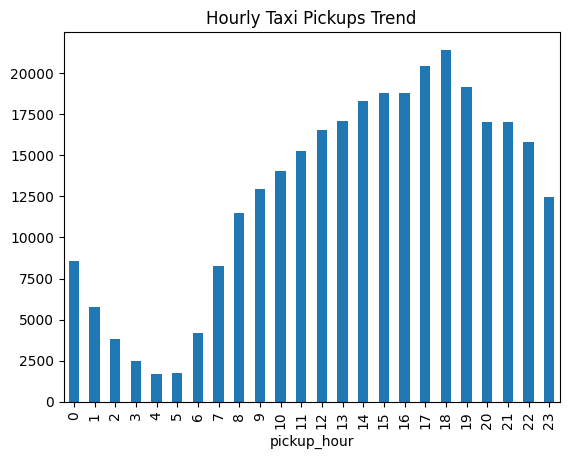

In [ ]:
# Find and show the hourly trends in taxi pickups
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour # Create a new column extracting the hour from tpep_pickup_datetime
df["pickup_hour"].value_counts().sort_index().plot(kind="bar", title="Hourly Taxi Pickups Trend") # Plot taxi pickup hourly trend

<Axes: title={'center': 'Daily Taxi Pickups Trend'}, xlabel='pickup_day'>

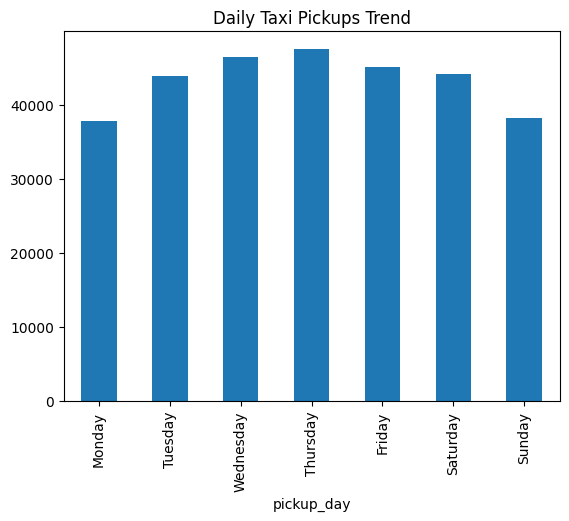

In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name() # Create a new column extracting day of the week from tpep_pickup_datetime
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"] # Order day of the week chronologically
df["pickup_day"].value_counts().reindex(day_order).plot(kind="bar", title="Daily Taxi Pickups Trend") # Plot taxi pickup daily trend with chronological day of the week order

<Axes: title={'center': 'Monthly Taxi Pickups Trend'}, xlabel='pickup_month'>

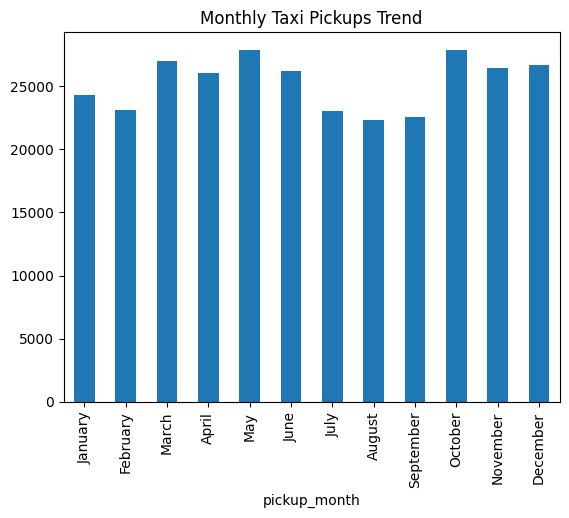

In [ ]:
# Show the monthly trends in pickups
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month_name() # Create a new column extracting day of the week from tpep_pickup_datetime
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"] # Order day of the week chronologically
df["pickup_month"].value_counts().reindex(month_order).plot(kind="bar", title="Monthly Taxi Pickups Trend") # Plot taxi pickup daily trend with chronological day of the week order

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse the above parameters
financial_params = [
    "fare_amount",
    "tip_amount",
    "total_amount",
    "trip_distance"
] # Define the financial parameters

for col in financial_params:
    neg_count = (df[col] < 0).sum()
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {neg_count} negative values, {zero_count} zero values") # Print each monetary column and number of records with negative values

fare_amount: 0 negative values, 93 zero values
tip_amount: 0 negative values, 69716 zero values
total_amount: 0 negative values, 39 zero values
trip_distance: 0 negative values, 5927 zero values


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a df with non zero entries for the selected parameters.
df = df[(df["fare_amount"] > 0) & (df["total_amount"] > 0)] # Will only filter out the zero entries of fare_amount and total_amount. These numbers are minor and unrealistic. On the other hand, tip_amount (passengers not tipping), trip_distance (same zone) could be zero, and the numbers are relatively high, hence avoid making assumption.

for col in financial_params:
    neg_count = (df[col] < 0).sum()
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zero values") # Double check after filter


fare_amount: 0 zero values
tip_amount: 69623 zero values
total_amount: 0 zero values
trip_distance: 5888 zero values


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

<Axes: title={'center': 'Monthly Revenue'}, xlabel='pickup_month'>

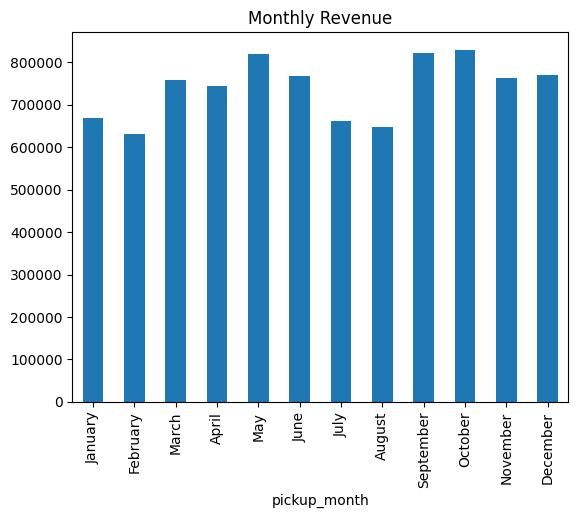

In [ ]:
# Group data by month and analyse monthly revenue
df.groupby(df["pickup_month"])["total_amount"].sum().reindex(month_order).plot(kind="bar", title="Monthly Revenue")

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [ ]:
# Calculate proportion of each quarter
df["pickup_quarter"] = df["tpep_pickup_datetime"].dt.quarter # Create a new column extracting Quarter from tpep_pickup_datetime
round((df["pickup_quarter"].value_counts(normalize=True) * 100), 2) # Calculate

,proportion
pickup_quarter,
4,26.69
2,26.40
1,24.53
3,22.38


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

<Axes: title={'center': 'Trip Fare vs Distance'}, xlabel='trip_distance', ylabel='fare_amount'>

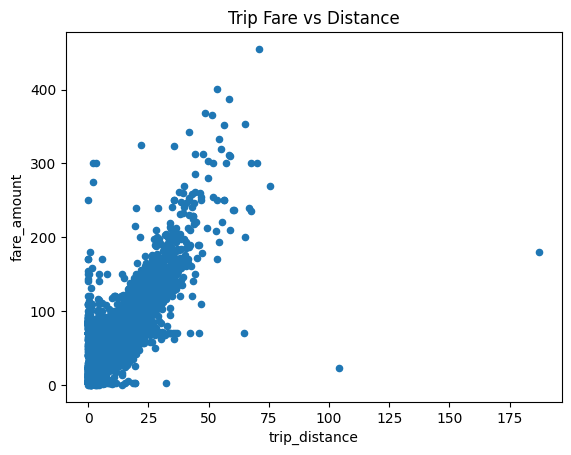

In [ ]:
# Show how trip fare is affected by distance
df[(df["fare_amount"] > 140000)] # Came across a potential outlier (140k in fare_amount, but only 0.7 miles in trip_distance). Will drop this entry.
df = df[df["fare_amount"] < 140000] # Drop the outlier
df[df["trip_distance"] > 0].plot.scatter(x="trip_distance", y="fare_amount", title="Trip Fare vs Distance") # Plot trip fare vs distance

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

<Axes: title={'center': 'Trip Fare vs Duration'}, xlabel='trip_duration', ylabel='fare_amount'>

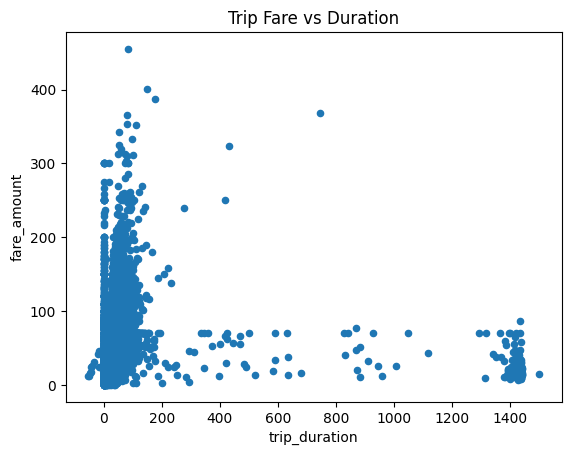

In [ ]:
# Show relationship between fare and trip duration
df.plot.scatter(x="trip_duration", y="fare_amount", title="Trip Fare vs Duration") # Reuse trip_duration column added earlier. Plot


<Axes: title={'center': 'Trip Fare vs Passenger Count'}, xlabel='passenger_count', ylabel='fare_amount'>

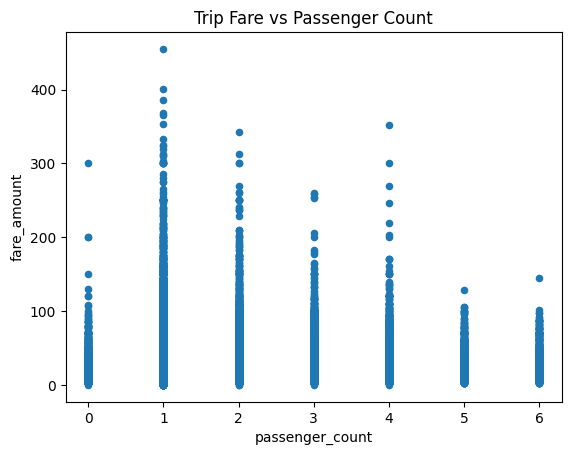

In [ ]:
# Show relationship between fare and number of passengers
df.plot.scatter(x="passenger_count", y="fare_amount", title="Trip Fare vs Passenger Count") #Plot

<Axes: title={'center': 'Tip Amount vs Trip Distance'}, xlabel='trip_distance', ylabel='tip_amount'>

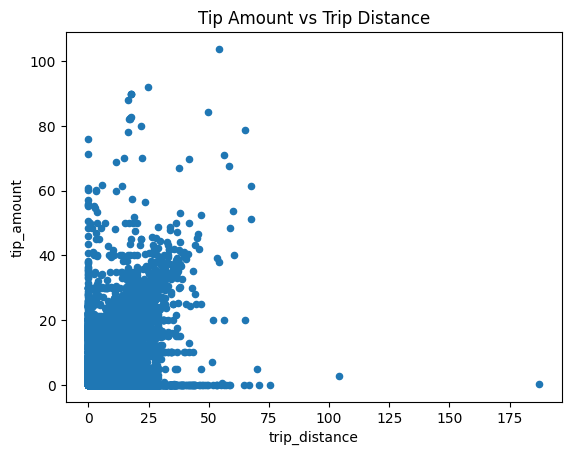

In [ ]:
# Show relationship between tip and trip distance
df.plot.scatter(x="trip_distance", y="tip_amount", title="Tip Amount vs Trip Distance") #Plot

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

<Axes: title={'center': 'Payment Type Distribution'}, ylabel='count'>

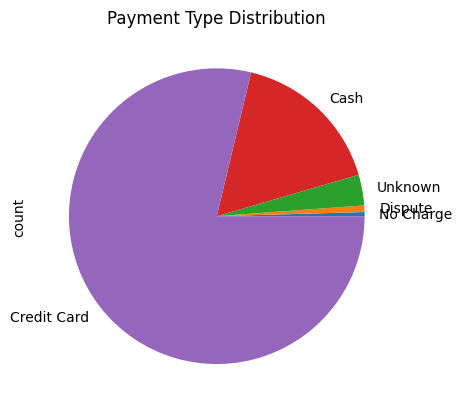

In [ ]:
# Analyse the distribution of different payment types (payment_type).
payment_map = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided Trip"
} # Mapping numerical values to meaningful values

df["payment_type"].map(payment_map).value_counts().sort_values().plot(kind="pie", title="Payment Type Distribution") # Plot

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file("/content/drive/MyDrive/Masters/Master - Data Science & AI - Upgrad/Core Curriculum/Data Analysis and Exploration/EDA Assignment - Mandatory/Taxi Zones/taxi_zones.shp") # Read the .shp file using gpd
zones.head(10)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."
5,6,0.150491,0.000606,Arrochar/Fort Wadsworth,6,Staten Island,"POLYGON ((966568.747 158679.855, 966615.256 15..."
6,7,0.107417,0.000390,Astoria,7,Queens,"POLYGON ((1010804.218 218919.641, 1011049.165 ..."
7,8,0.027591,0.000027,Astoria Park,8,Queens,"POLYGON ((1005482.276 221686.466, 1005304.898 ..."
8,9,0.099784,0.000338,Auburndale,9,Queens,"POLYGON ((1043803.993 216615.925, 1043849.708 ..."
9,10,0.099839,0.000436,Baisley Park,10,Queens,"POLYGON ((1044355.072 190734.321, 1044612.122 ..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

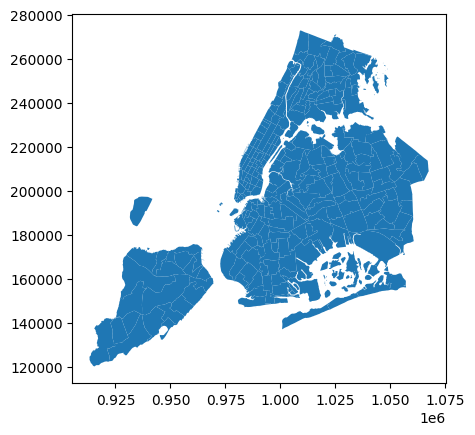

In [ ]:
# print(zones.info())
print(zones.info())
# zones.plot()
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID
df_merged = df.merge(zones, left_on="PULocationID", right_on="LocationID", how="left")
df_merged.info()
df_merged.head(3).transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303162 entries, 0 to 303161
Data columns (total 31 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               303162 non-null  int64         
 1   tpep_pickup_datetime   303162 non-null  datetime64[us]
 2   tpep_dropoff_datetime  303162 non-null  datetime64[us]
 3   passenger_count        303162 non-null  float64       
 4   trip_distance          303162 non-null  float64       
 5   RatecodeID             303162 non-null  float64       
 6   store_and_fwd_flag     303162 non-null  object        
 7   PULocationID           303162 non-null  int64         
 8   DOLocationID           303162 non-null  int64         
 9   payment_type           303162 non-null  int64         
 10  fare_amount            303162 non-null  float64       
 11  extra                  303161 non-null  float64       
 12  mta_tax                303162 non-null  floa

,0,1,2
VendorID,2,2,2
tpep_pickup_datetime,2023-01-01 00:07:18,2023-01-01 00:16:41,2023-01-01 00:14:03
tpep_dropoff_datetime,2023-01-01 00:23:15,2023-01-01 00:21:46,2023-01-01 00:24:36
passenger_count,1.0,2.0,3.0
trip_distance,7.74,1.24,1.44
RatecodeID,1.0,1.0,1.0
store_and_fwd_flag,N,N,N
PULocationID,138,161,237
DOLocationID,256,237,141
payment_type,2,1,2


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips
num_trips_per_locationID = df_merged['LocationID'].value_counts().reset_index()
num_trips_per_zone = df_merged['zone'].value_counts()

NameError: name 'df_merged' is not defined

**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Add the number of trips for each zone to the zones dataframe
num_trips_per_locationID.rename(columns={'count': 'trip_count'}, inplace=True)
zones_with_trips = zones.merge(num_trips_per_locationID,on="LocationID", how="left")
zones_with_trips.info()
zones_with_trips.head().sort_values(by="trip_count", ascending=False)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
 7   trip_count  242 non-null    float64 
dtypes: float64(3), geometry(1), int32(2), object(2)
memory usage: 14.5+ KB


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",359.0
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",43.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",10.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",2.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

<Axes: >

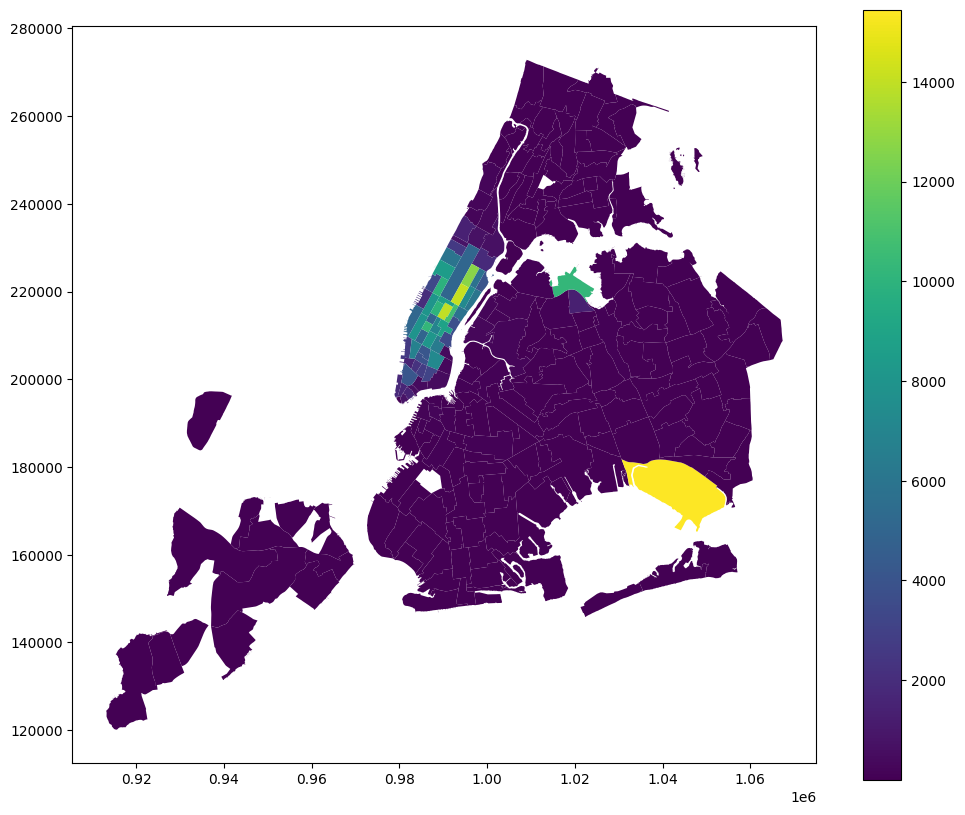

In [ ]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
zones_with_trips.plot(column="trip_count", ax=ax, legend=True)

In [ ]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trips.sort_values(by="trip_count", ascending=False)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",15450.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",14094.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",13975.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",12726.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",10790.0
...,...,...,...,...,...,...,...,...
175,176,0.151995,0.000658,Oakwood,176,Staten Island,"POLYGON ((950393.94 148827.195, 950393.983 148...",NaN
182,183,0.039826,0.000095,Pelham Bay,183,Bronx,"POLYGON ((1029414.164 246587.728, 1029380.19 2...",NaN
183,184,0.260816,0.001989,Pelham Bay Park,184,Bronx,"MULTIPOLYGON (((1037536.693 262105.37, 1037634...",NaN
198,199,0.077809,0.000289,Rikers Island,199,Bronx,"POLYGON ((1015023.713 230286.759, 1015093.307 ...",NaN


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day
df["trip_duration_hours"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 3600 # New column trip duration (in hours) derived from existing columns
df["avg_speed_mph"] = (df["trip_distance"] / df["trip_duration_hours"]) # New column avg speed mph for each trip
df["avg_speed_mph"].describe() # Check for negatives and outliers
df_speed = df[(df["avg_speed_mph"] > 0) & (df["avg_speed_mph"] < 200)]  # Remove negatives and outliers (assuming 200 mph is the upper bound)
df_speed["avg_speed_mph"].describe() # Double check

df_speed.groupby(["PULocationID", "DOLocationID"])["avg_speed_mph"].mean().reset_index().sort_values(by="avg_speed_mph", ascending=True) # Group by route (PUlocation vs DOlocation), find mean, sort values asc


,PULocationID,DOLocationID,avg_speed_mph
4259,134,265,0.073831
7580,220,236,0.096878
3914,128,128,0.115385
8216,231,247,0.142979
901,42,89,0.216998
...,...,...,...
1708,66,107,64.133333
191,10,218,65.226860
6648,170,197,76.664789
1595,62,62,81.000000


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

<Axes: title={'center': 'Busiest Taxi Hours'}, xlabel='pickup_hour'>

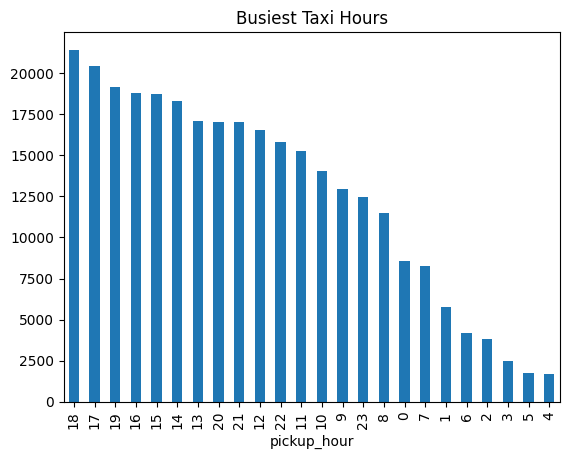

In [ ]:
# Visualise the number of trips per hour and find the busiest hour
trips_per_hour_sampled = df["pickup_hour"].value_counts().sort_values(ascending=False)

trips_per_hour_sampled.plot(kind="bar", title="Busiest Taxi Hours") # Plot taxi pickup hourly trend

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

<Axes: title={'center': 'Top 5 Busiest Taxi Hours'}, xlabel='pickup_hour', ylabel='Number of trips (millions)'>

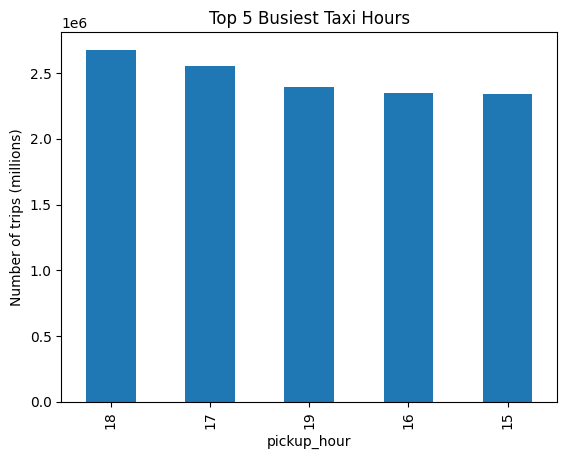

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.008

trips_per_hour_sampled_top5 = trips_per_hour_sampled.sort_values(ascending=False).head(5) #Add top 5 (sampled) to a variable

trips_per_hour_actual_top5 = trips_per_hour_sampled_top5 / sample_fraction # Find the top 5 (Actual)

trips_per_hour_actual_top5.plot(kind="bar", title="Top 5 Busiest Taxi Hours", ylabel="Number of trips (millions)") # Plot

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

<Axes: title={'center': 'Hourly Taxi Traffic: Weekday vs Weekend'}, xlabel='Hour of day', ylabel='Number of trips'>

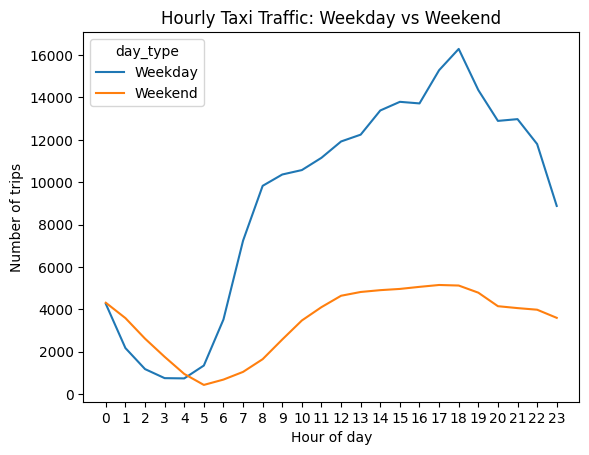

In [ ]:
# Compare traffic trends for the week days and weekends
df["pickup_day"].value_counts() #Doubble check the pickup_day column represents the day of week and check the values.
df["day_type"] = df["pickup_day"].apply(lambda x: "Weekend" if x in ["Saturday","Sunday"] else "Weekday") #New column to label weekend vs weekday
df.groupby(["pickup_hour","day_type"])["pickup_hour"].count().unstack().plot(kind="line", title="Hourly Taxi Traffic: Weekday vs Weekend",xlabel="Hour of day", ylabel="Number of trips", xticks=range(24))

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
# Find top 10 pickup and dropoff zones

# Pickup
df_merged.rename(columns={"zone": "pickup_zone"}, inplace=True) #Rename zone to pickup_zone, later there will be dropoff_zone
top10_pickup_zones = df_merged["pickup_zone"].value_counts().head(10).index #Identify top 10 pickup zones by number of trips across all hours
pickup_hourly_trend = df_merged[df_merged["pickup_zone"].isin(top10_pickup_zones)].groupby(["pickup_hour", "pickup_zone"]).size().unstack().plot(kind="line",title="Top 10 Pickup Zones: Hourly Pickup Trend",xlabel="Hour of day",ylabel="Number of trips",xticks=range(24)) #Seggegrate the trip records of top 10 pickup zones, then group and plot

NameError: name 'df_merged' is not defined

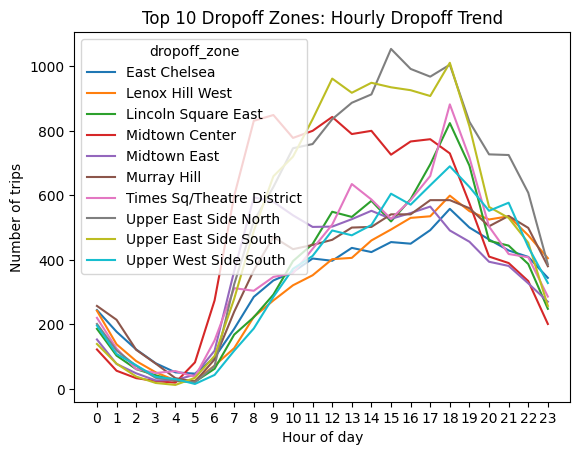

In [ ]:
# Dropoff
df_merged = df_merged.merge(zones[["LocationID", "zone"]],left_on="DOLocationID",right_on="LocationID",how="left").rename(columns={"zone": "dropoff_zone"}) #Merged zone names from zones df and rename it
df_merged["dropoff_hour"] = df_merged["tpep_dropoff_datetime"].dt.hour #New column dropoff_hour extracting from tpep_dropoff_datetime
top10_dropoff_zones = df_merged["dropoff_zone"].value_counts().head(10).index #Identify top 10 dropoff zones by no of trips across all hours
dropoff_hourly_trend = df_merged[df_merged["dropoff_zone"].isin(top10_dropoff_zones)].groupby(["dropoff_hour", "dropoff_zone"]).size().unstack().plot(kind="line",title="Top 10 Dropoff Zones: Hourly Dropoff Trend",xlabel="Hour of day",ylabel="Number of trips",xticks=range(24)) #Seggegrate the trip records of top 10 dropoff zones, then group and plot

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = df_merged["pickup_zone"].value_counts() #Count no of pickups in each zones
dropoff_counts = df_merged["dropoff_zone"].value_counts() #Count no of dropoffs in each zone
zone_counts = pd.DataFrame({"pickup_count": pickup_counts,"dropoff_count": dropoff_counts}) #Combine the counts into one df
zone_counts = zone_counts[zone_counts["dropoff_count"] > 0] #Drop the zero dropoff_count to avoid error when dividing
zone_counts["pickup_drop_ratio"] = (zone_counts["pickup_count"] /zone_counts["dropoff_count"]) #New column computes the ratio

top10_highest = zone_counts.sort_values("pickup_drop_ratio",ascending=False).head(10) #Find the top10 highest ratio
top10_lowest = zone_counts.sort_values("pickup_drop_ratio",ascending=True).head(10) #Find the top10 lowest ratio

top10_highest,top10_lowest

(                              pickup_count  dropoff_count  pickup_drop_ratio
 East Elmhurst                       1356.0            171           7.929825
 JFK Airport                        15484.0           3562           4.346996
 LaGuardia Airport                  10226.0           3881           2.634888
 Penn Station/Madison Sq West       10201.0           6756           1.509917
 West Village                        6753.0           4943           1.366174
 Central Park                        5070.0           3727           1.360343
 Greenwich Village South             3921.0           2940           1.333673
 Midtown East                       10792.0           8609           1.253572
 Garment District                    4905.0           4132           1.187076
 Midtown Center                     13976.0          11806           1.183805,
                      pickup_count  dropoff_count  pickup_drop_ratio
 Whitestone                    2.0             59           0.033898
 Oc

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_trips = df_merged[(df_merged["dropoff_hour"] >= 23) | (df_merged["pickup_hour"] <= 5)] #New df only contains night trips
night_pickups = night_trips["pickup_zone"].value_counts().head(10) #Find top10 night trip pickup zones no of trips
night_dropoffs = night_trips["dropoff_zone"].value_counts().head(10) #Find top10 night trip dropoff zones by no of trips

night_pickups, night_dropoffs

(pickup_zone
 East Village                    2641
 JFK Airport                     2428
 West Village                    2145
 Clinton East                    1760
 Lower East Side                 1642
 Times Sq/Theatre District       1471
 Greenwich Village South         1439
 Penn Station/Madison Sq West    1156
 Midtown South                   1062
 East Chelsea                    1024
 Name: count, dtype: int64,
 dropoff_zone
 East Village                 1450
 Clinton East                 1204
 Murray Hill                  1047
 East Chelsea                 1014
 Gramercy                      982
 Lenox Hill West               913
 Yorkville West                886
 Upper East Side North         816
 Times Sq/Theatre District     800
 West Village                  798
 Name: count, dtype: int64)

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)
df_merged["trip_period"] = ((df_merged["dropoff_hour"] >= 23) | (df_merged["pickup_hour"] <= 5)).map({True: "Night",False: "Day"}) #New column labelling day/night trips

revenue_share = (df_merged.groupby("trip_period")["total_amount"].sum() / df_merged["total_amount"].sum()) #Calculate revenue share
revenue_share

,total_amount
trip_period,
Day,0.872547
Night,0.127453


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts
df_merged = df_merged[(df_merged["passenger_count"] > 0) & (df_merged["trip_distance"] > 0)] # Remove entries with trip_distance or passenger_count = 0
df_merged["fare_permile_perpassenger_pertrip"] = (df_merged["fare_amount"] / (df_merged["trip_distance"] * df_merged["passenger_count"])) # New column fare_permile_perpassenger_pertrip
df_merged.groupby("passenger_count")["fare_permile_perpassenger_pertrip"].mean() #Avg fare per mile per passenger for each passenger count group

,fare_permile_perpassenger_pertrip
passenger_count,
1.0,10.767270
2.0,6.219944
3.0,4.210811
4.0,5.328751
5.0,1.578998
6.0,1.277219


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

<Axes: title={'center': 'Hourly and Daily Fare Trend'}, xlabel='Hour of day', ylabel='Average fare'>

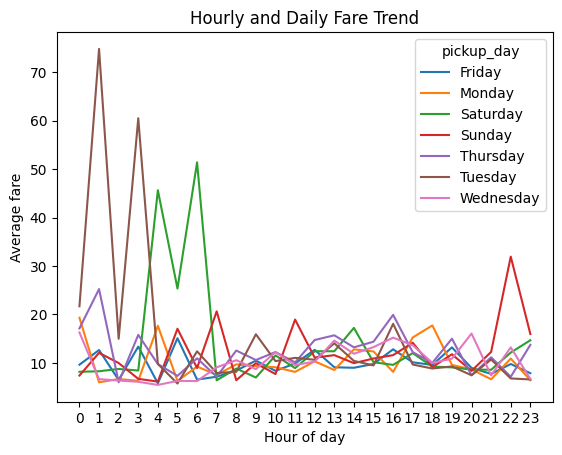

In [ ]:
# Compare the average fare per mile for different days and for different times of the day
df_merged["fare_permile_pertrip"] = (df_merged["fare_amount"] / df_merged["trip_distance"]) #New column fare_permile_pertrip
df_merged.groupby(["pickup_hour","pickup_day"])["fare_permile_pertrip"].mean().unstack().plot(kind="line",title="Hourly and Daily Fare Trend",xlabel="Hour of day",ylabel="Average fare",xticks=range(24))


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

<Axes: title={'center': 'Fare Trend by Vendors'}, xlabel='Hour of day', ylabel='Average fare'>

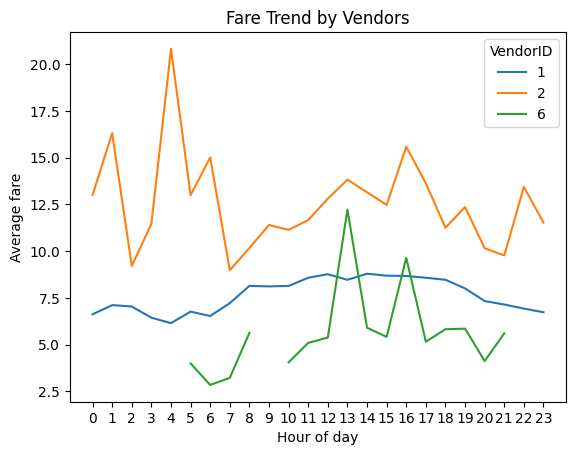

In [ ]:
# Compare fare per mile for different vendors
df_merged.groupby(["pickup_hour","VendorID"])["fare_permile_pertrip"].mean().unstack().plot(kind="line",title="Fare Trend by Vendors",xlabel="Hour of day",ylabel="Average fare",xticks=range(24))

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


<Axes: title={'center': 'Fare by Vendors across Distance Tiers'}, xlabel='Distance tier', ylabel='Average fare'>

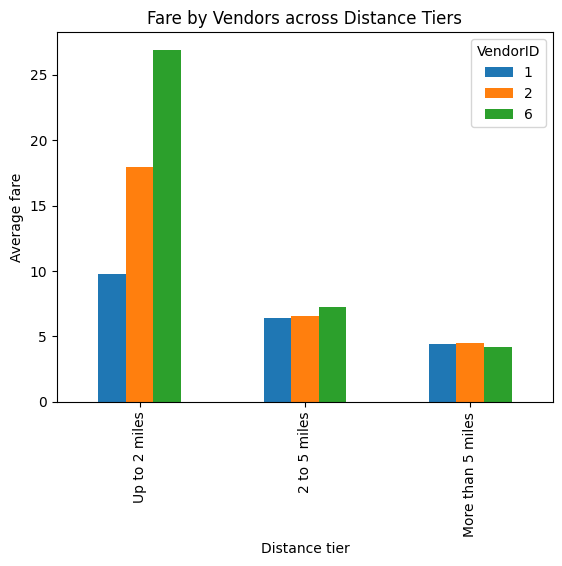

In [ ]:
# Defining distance tiers
def distance_bucket(d):
    if d <= 2:
        return "Up to 2 miles"
    elif d <= 5:
        return "2 to 5 miles"
    else:
        return "More than 5 miles"

df_merged["distance_tier"] = df_merged["trip_distance"].apply(distance_bucket)
tier_order = ["Up to 2 miles","2 to 5 miles","More than 5 miles"]
df_merged.groupby(["distance_tier","VendorID"])["fare_permile_pertrip"].mean().unstack().reindex(tier_order).plot(kind="bar",title="Fare by Vendors across Distance Tiers",xlabel="Distance tier",ylabel="Average fare")


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
df_merged["tip_percentage"] = (df_merged["tip_amount"] / df_merged["fare_amount"] * 100) #New column tip_percentage
df_merged.groupby(["distance_tier"])["tip_percentage"].mean().reindex(tier_order) #Tip based on tier distance
df_merged.groupby(["passenger_count"])["tip_percentage"].mean().sort_values(ascending=False) #Tip based on passenger count
df_merged.groupby(["pickup_hour"])["tip_percentage"].mean().sort_values(ascending=False).head(5) #Tip based on pickup hour

,tip_percentage
pickup_hour,
18,22.038931
19,22.038822
17,21.583306
21,21.398236
20,21.245253


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

<Axes: title={'center': 'Hourly and Daily Avg Passenger per Trip Trend'}, xlabel='Hour of day', ylabel='Avg passenger per trip'>

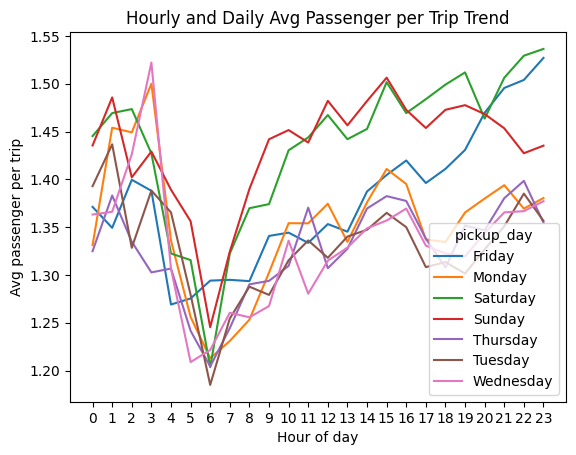

In [ ]:
# See how passenger count varies across hours and days
df_merged.groupby(["pickup_hour","pickup_day"])["passenger_count"].mean().unstack().plot(kind="line",title="Hourly and Daily Avg Passenger per Trip Trend",xlabel="Hour of day",ylabel="Avg passenger per trip",xticks=range(24))


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

<Axes: title={'center': 'Top 10 Zones with Lowest Avg Passengers per Trip'}, xlabel='Zone', ylabel='Avg passenger per trip'>

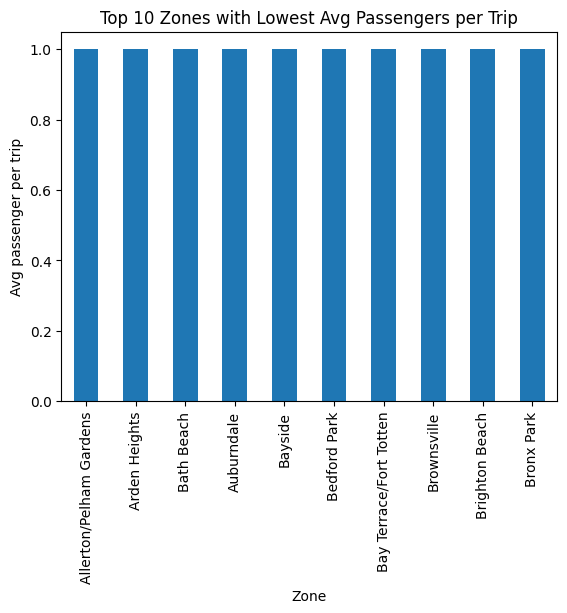

In [ ]:
# How does passenger count vary across zones
df_merged.groupby(["pickup_zone"])["passenger_count"].mean().sort_values(ascending=False).head(10).plot(kind="bar",title="Top 10 Zones with Highest Avg Passengers per Trip",xlabel="Zone",ylabel="Avg passenger per trip")
df_merged.groupby(["pickup_zone"])["passenger_count"].mean().sort_values(ascending=True).head(10).plot(kind="bar",title="Top 10 Zones with Lowest Avg Passengers per Trip",xlabel="Zone",ylabel="Avg passenger per trip")


In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

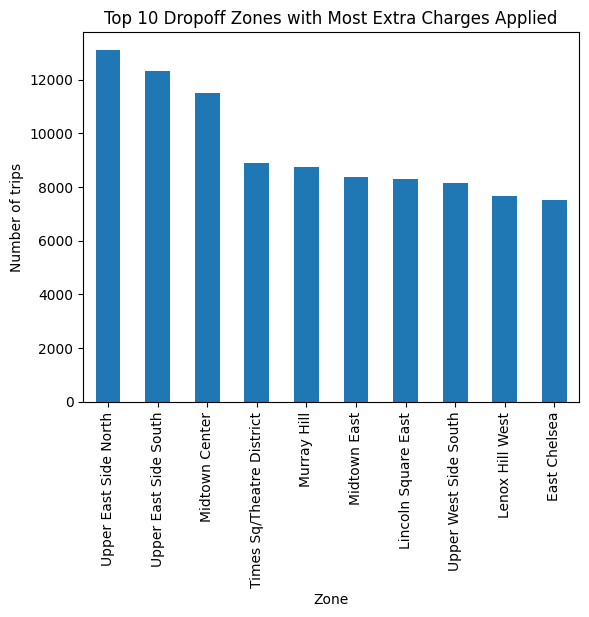

In [ ]:
# How often is each surcharge applied?
df_merged["extra_charge_applied"] = ((df_merged["extra"] > 0) |(df_merged["congestion_surcharge"] > 0) |(df_merged["airport_fee"] > 0) |(df_merged["tolls_amount"] > 0)) # New column if any of the extra charges entries have values > 0, then this is recorded as Yes, else No.

extra_by_pickup_zone = df_merged.groupby("pickup_zone")["extra_charge_applied"].count().sort_values(ascending=False).head(10).plot(kind="bar",title="Top 10 Pickup Zones with Most Extra Charges Applied",xlabel="Zone",ylabel="Number of trips") #Identify top 10 pickup zones with most number of times extra charges applied

extra_by_dropoff_zone = df_merged.groupby("dropoff_zone")["extra_charge_applied"].count().sort_values(ascending=False).head(10).plot(kind="bar",title="Top 10 Dropoff Zones with Most Extra Charges Applied",xlabel="Zone",ylabel="Number of trips") #Identify top 10 dropoff zones with most number of times extra charges applied

extra_by_pickup_hour = df_merged.groupby("pickup_hour")["extra_charge_applied"].count().sort_values(ascending=False).plot(kind="bar",title="Pickup Hours with Most Extra Charges Applied",xlabel="Hour of day",ylabel="Number of trips", xticks=range(24)) #Hour of the day with the most number of trips with extra charge applied



## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.